In [11]:
# %matplotlib widget
import sys
sys.path.append('..')

import os
import sys
import numpy as np
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm
from mpl_toolkits import mplot3d
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
import math
from IPython.display import HTML
from tqdm import tqdm
import random
from numpy.lib import recfunctions as rfn

from sklearn.cluster import DBSCAN
from scipy.interpolate import interp1d
from scipy.spatial import KDTree
from scipy.interpolate import interpn
# import cupy as cp
import time
import numba as nb

# 画图部分
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import ImageGrid
from functools import partial
import matplotlib.cm as cm

# ROC曲线部分
from sklearn.metrics import roc_curve, auc
from sklearn import metrics

# 插值
import torch
# import torch.cuda as cuda
from scipy.interpolate import griddata

# 系数拟合部分
from scipy.optimize import curve_fit
from sklearn import svm

In [12]:
# 概率比较部分
from scipy.special import gammaln
# import torch.distributions as dist

# 位置重建函数
import position_rec as pos

import DE
from DE import DESimulation

import os
import glob
import re

In [13]:
from importlib import reload  
  
reload(DE)
from DE import DESimulation

CEVNS数据参数准备
=====

In [14]:
data = np.load("./sim_config/cevns_sim.npz")
data_original = np.load("data/e_spectrum_relics.npz")

In [15]:
# 创建一个字典来复制数据
new_data_dict = {key: data[key] for key in data.files}

# 修改特定的数据, 按照100倍曝光量模拟3电子及以上事件
new_data_dict['CEvNS'] = data_original['CEvNS']* 32 * 100

new_data_dict['CEvNS'][:3] = 1

print(new_data_dict['CEvNS'])

np.savez('sim_config/cevns_sim_100_3e.npz',**new_data_dict)

[1.00000000e+00 1.00000000e+00 1.00000000e+00 2.27016221e+06
 9.79127136e+05 4.44068941e+05 2.03188205e+05 9.19509321e+04
 4.07237142e+04 1.75417887e+04 7.32063127e+03 2.95266494e+03
 1.14930982e+03 4.31395124e+02 1.56094737e+02 5.44473810e+01
 1.83122688e+01 5.94095600e+00 1.86013399e+00 5.62429498e-01]


In [16]:
muon_track_file_load_once = 50
param = 0

DE_sim = DESimulation('sim_config/CEvNS_3-10.yaml')

muon_file_list = []
for i in range(muon_track_file_load_once):
    # print(i)
    file_index = param * muon_track_file_load_once + i
    filename = DE_sim.muon_track_file + \
        "muon_track." + str(file_index) + ('.npy')
    # print(filename)
    muon_file_list.append(filename)

In [17]:
DE_sim.generate_muon_points(muon_file_list)
print(" \n Sim muon last time:{}h \n".format(DE_sim.time_range/3600))
print(DE_sim.cevns_e_spectrum)
print(DE_sim.cevns_e_num)

DE_sim.generate_CEVNS_points()
DE_sim.generate_CEVNS_pattern()

DE_sim.CEVNS_position_recon()

DE_sim.generate_CEVNS_recon_pattern()
DE_sim.CEVNS_sp_cor()


  4%|███████▌                                                                                                                                                                                      | 2/50 [00:00<00:02, 18.44it/s]

./muon_track/muon_track.0.npy
./muon_track/muon_track.1.npy
./muon_track/muon_track.2.npy
./muon_track/muon_track.3.npy


 16%|██████████████████████████████▍                                                                                                                                                               | 8/50 [00:00<00:01, 23.46it/s]

./muon_track/muon_track.4.npy
./muon_track/muon_track.5.npy
./muon_track/muon_track.6.npy
./muon_track/muon_track.7.npy
./muon_track/muon_track.8.npy
./muon_track/muon_track.9.npy


 30%|████████████████████████████████████████████████████████▋                                                                                                                                    | 15/50 [00:00<00:01, 25.04it/s]

...

平均电子数：  8.006275382457835
last_muon_id.shape:  (17541,)
last_muon_id[-10:]:  [157061 157063 157071 157112 157145 157169 157177 157212 157216 157250]
0
0 17541


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17541/17541 [00:01<00:00, 14038.79it/s]


平均电子数：  8.994696926253921
last_muon_id.shape:  (7320,)
last_muon_id[-10:]:  [157101 157114 157128 157146 157168 157177 157184 157227 157246 157250]
0
0 7320


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7320/7320 [00:00<00:00, 13731.35it/s]


平均电子数：  9.999251451778976


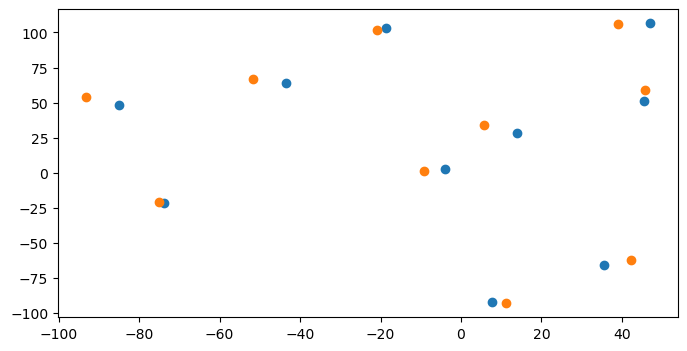

In [18]:
fig = plt.figure(figsize=(8, 4), dpi=100)
plt.scatter(DE_sim.cevns_points[3]["pos_recon"][:10]['xd'], DE_sim.cevns_points[3]["pos_recon"][:10]['yd'])
plt.scatter(DE_sim.cevns_points[3]["pos_original"][:10]['xd'], DE_sim.cevns_points[3]["pos_original"][:10]['yd'])

plt.show()

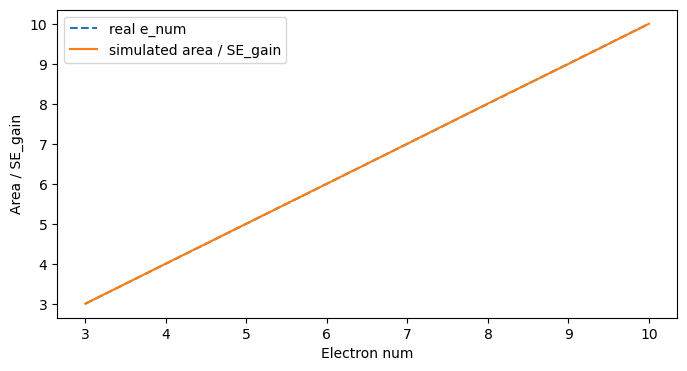

[1.00018074 1.00063166 1.00033963 1.00012097 1.00007394 1.00078442
 0.99941077 0.99992515]


In [19]:
average_area_list = []
for e_num in DE_sim.cevns_e_num:
    average_area = np.mean(np.sum(DE_sim.cevns_points[e_num - 1]["pe_by_area"],axis = 1)) / 30
    average_area_list.append(average_area)
    
fig = plt.figure(figsize=(8, 4), dpi=100)
plt.plot(DE_sim.cevns_e_num[2:], DE_sim.cevns_e_num[2:], linestyle='--', label = 'real e_num')
plt.plot(DE_sim.cevns_e_num[2:], average_area_list[2:], label = 'simulated area / SE_gain')
plt.xlabel('Electron num')
plt.ylabel('Area / SE_gain')
plt.legend()
plt.savefig("figure/sim_area_divert.png")
plt.show()

print(average_area_list[2:] / DE_sim.cevns_e_num[2:])

In [21]:
cevns_points = np.concatenate((DE_sim.cevns_points))

def calculate_poisson_probabilities_log(data_array, mean_array):
    # 计算每个元素的对数概率
    log_probabilities = -mean_array + data_array * np.log(mean_array) - gammaln(data_array + 1)
    return log_probabilities

# 定义cevns点的三参数
cevns_info = np.zeros(len(cevns_points),dtype = np.dtype([('area', '<f8'),('st_cor', '<f8'),('pattern', '<f8'),('e_num','uint32')]))
cevns_info['area'] = np.sum(cevns_points['pe_by_area'],axis = 1)
cevns_info['st_cor'] = np.log(cevns_points['st_cor'])
cevns_info['pattern'] = np.sum(calculate_poisson_probabilities_log(
         cevns_points['pe_by_area'][:,:64], cevns_points['recons_light_pattern'][:,:64]),axis = 1)
cevns_info['e_num'] = cevns_points['num_e']

np.savez('sim_result/cevns_pattern.npz', 
             cevns_pattern_coefficient=cevns_info['pattern'],
             cevns_area=cevns_info['area'],
             cevns_e_num=cevns_info['e_num'],
             cevns_st_cor = cevns_info['st_cor'],
            )


In [11]:
def sim_list_files(path,N = 18459):
    files = glob.glob(os.path.join(path, '*.npz'))  # 获取所有匹配的文件路径名
    print(len(files))
    files = sorted(files, key=lambda x: int(re.match(r'(\d+)', os.path.basename(x)).group(1)))  # 提取文件名中的数值部分并以其为键进行排序
    # for file in files[:N]:
    #     print(file)
    return files

def pattern_list_files(path,N = 18459):
    files = glob.glob(os.path.join(path, '*.npz'))  # 获取所有匹配的文件路径名
    print(len(files))
    files = sorted(files, key=lambda x: int(re.match(r'pattern_coefficient_(\d+)\.npz', os.path.basename(x)).group(1)))  # 提取文件名中的数值部分并以其为键进行排序
    # for file in files[:N]:
    #     print(file)
    return files
        

file_list = sim_list_files("/home/cchang/RELICS_DE_sim_/new_S2_pattern_sim/DE_result_0822")
pattern_file_list = pattern_list_files("./sim_result")

18459
18459


In [18]:
# 从原有的模拟数据中摘取pattern相关内容
pile_up_pattern_coefficient_list = []
pile_up_area_list = []
pile_up_e_num_list = []
pile_up_sp_cor_list = []

for i in tqdm(range(len(pattern_files))):
    file = np.load(pattern_files[i])
    pile_up_pattern_coefficient = file['pile_up_pattern_coefficient']
    pile_up_area =  file["pile_up_area"]
    pile_up_e_num =  file["pile_up_e_num"]
    pile_up_sp_cor = file['pile_up_sp_cor']
    
    pile_up_pattern_coefficient_list.append(pile_up_pattern_coefficient)
    pile_up_area_list.append(pile_up_area)
    pile_up_e_num_list.append(pile_up_e_num)
    pile_up_sp_cor_list.append(pile_up_sp_cor)
    
pile_up_pattern_coefficient = np.concatenate(pile_up_pattern_coefficient_list)
pile_up_area = np.concatenate(pile_up_area_list)
pile_up_e_num = np.concatenate(pile_up_e_num_list)
pile_up_sp_cor = np.concatenate(pile_up_sp_cor_list)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18459/18459 [36:17<00:00,  8.48it/s]


In [31]:
DE_info = np.zeros(len(pile_up_pattern_coefficient),dtype = np.dtype([('area', '<f8'),('st_cor', '<f8'),('pattern', '<f8'),('e_num','uint32')]))
DE_info['area'] = pile_up_area
DE_info['st_cor'] = pile_up_sp_cor
DE_info['pattern'] = pile_up_pattern_coefficient
DE_info['e_num'] = pile_up_e_num

np.savez('sim_result/DE_pattern.npz', 
             DE_pattern_coefficient=DE_info['pattern'],
             DE_area=DE_info['area'],
             DE_e_num=DE_info['e_num'],
             DE_st_cor = DE_info['st_cor'],
            )

In [ ]:
x_bins = np.arange(-10,15,0.1)
y_bins = np.arange(-250,-0,1)

# roi_mask_cevns = (cevns_info['area'] > 120) * (cevns_info['area'] < 240)


plt.figure(figsize=(6,6))  # 调整 figsize 参数以设置合适的宽度和高度
#plt.hist2d(real_space_time_cor_veto, real_log_l_veto_4, bins=500 , cmap='hot', norm=LogNorm(),alpha = 0.7,label='Real Event')
#plt.colorbar(pad = -0.01)

# H = plt.hist2d(cevns_info['st_cor'], cevns_info['pattern'],  bins = [x_bins, y_bins], norm=LogNorm(),alpha = 0.5,label = 'CEvNS Event', cmap='cool')
H = plt.hist2d(pile_up_sp_cor, pile_up_pattern_coefficient,  bins = [x_bins, y_bins], norm=LogNorm(),alpha = 1,label = 'CEvNS Event')
#mask = test_DE_sim.CEVNS_sp_cor[0] > 0
# H = plt.hist2d(np.log(test_DE_sim.CEVNS_sp_cor[0][mask]), CEVNS_pattern_possion[0][mask],  bins = 500, cmap='hot', norm=LogNorm(),alpha = 0.7,label = 'CEVNS Event')
plt.xlabel(r'$\mathrm{Spacetime\  Correlation\ Coeffieicnt}$')
plt.ylabel(r'$\mathrm{Pattern\ Coefficien}$')
# plt.title('3e')
plt.grid()
# plt.savefig("Pattern_dis.png")
plt.show()

In [ ]:
pile_up_area_spectrum,bins_edge = np.histogram(pile_up_area, bins=np.arange(90,301,10))
# cevns_spectrum_original,bins_edge = np.histogram(cevns_info_area['area'], bins=np.arange(90,301,10))

In [ ]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# 创建一个柱状图并添加误差条
ax.bar((bins_edge[1:] + bins_edge[:-1])/2, pile_up_area_spectrum / 32 / (0.85 / 10 * 1000) / 10, edgecolor = "black", label = "DE original",width=10,)
ax.bar((bins_edge[1:] + bins_edge[:-1])/2, pile_up_area_spectrum / 32 / (0.85 / 10 * 1000) / 10 * 0.00005, edgecolor = "black", label = "DE after Pattern Cut",width=10,)

ax.set_xlabel(r"$\mathrm{S2\ [PE]}$")
ax.set_ylabel(r"$\mathrm{Rate\ [kg^{-1} day^{-1} pe^{-1}]}$")
ax.set_yscale("log")

# 设置y轴的刻度为每个10的n次方
# ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0))
# ax.tick_params(direction='in')
# 增加背景刻度线
ax.grid(which='major', axis='y')
ax.set_ylim(1e-7, 1e4)  
ax.set_xlim(90, 300)  
# 添加阴影覆盖 x > 120 的区域  
ax.axvspan(80, 120, color='gray', alpha=0.8)  
plt.legend()
plt.savefig("figure/Expected_DE_rate.png")

plt.show()

In [ ]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# 创建一个柱状图并添加误差条
ax.bar((bins_edge[1:] + bins_edge[:-1])/2, pile_up_area_spectrum * 10, edgecolor = "black", label = "DE original",width=10,)
ax.bar((bins_edge[1:] + bins_edge[:-1])/2, pile_up_area_spectrum * 10 * 0.00005, edgecolor = "black", label = "DE original",width=10,)
ax.set_xlabel(r"$\mathrm{S2\ [PE]}$")
ax.set_ylabel(r"$\mathrm{Rate\ [year^{-1}]}$")
ax.set_yscale("log")

# 设置y轴的刻度为每个10的n次方
# ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0))
# ax.tick_params(direction='in')
# 增加背景刻度线
ax.grid(which='major', axis='y')
ax.set_ylim(1e-3, 1e9) 
ax.set_xlim(90, 300)  
# 添加阴影覆盖 x > 120 的区域  
ax.axvspan(80, 120, color='gray', alpha=0.8)
plt.legend()
plt.savefig("figure/Expected_DE_rate_year.png")

plt.show()

针对不同面积区域分bin
=======

In [48]:
#PE REGION: 120-130
DE_pe_mask = (DE_info['area'] > 120) & (DE_info['area'] < 130)
cevns_pe_mask = (cevns_info['area'] > 120) & (cevns_info['area'] < 130)

DE_bins = DE_info[DE_pe_mask]
cevns_bins = cevns_info[cevns_pe_mask]

In [46]:
exposure = []
k_st_list = np.arange(5,7.5,0.1)
k_list = []
score_cevns = 0

for k_st in tqdm(k_st_list):
    exposure_k = []
    score_cevns = cevns_bins['pattern'] - (k_st * cevns_bins['st_cor']) 
    score_DE = DE_bins['pattern'] - (k_st * DE_bins['st_cor'])
    b = np.percentile(score_DE, 100-0.005)
    k_list.append([k_st,b])
    exposure.append(len(score_cevns[score_cevns>b])/len(score_cevns))
exposure = np.array(exposure)

# 找到最大值的索引
index_of_max = np.argmax(exposure)
print(k_list[index_of_max],np.max(exposure))
k_st_area, b_area = k_list[index_of_max]
print(k_st_area, b_area)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:01<00:00, 24.34it/s]

[5.899999999999997, -96.29803906619506] 0.6116027188042857
5.899999999999997 -96.29803906619506


In [47]:
print(k_st_area, b_area)

5.899999999999997 -96.29803906619506


  0%|                                                                                                                                                                                                      | 0/18 [00:00<?, ?it/s]

280.03655


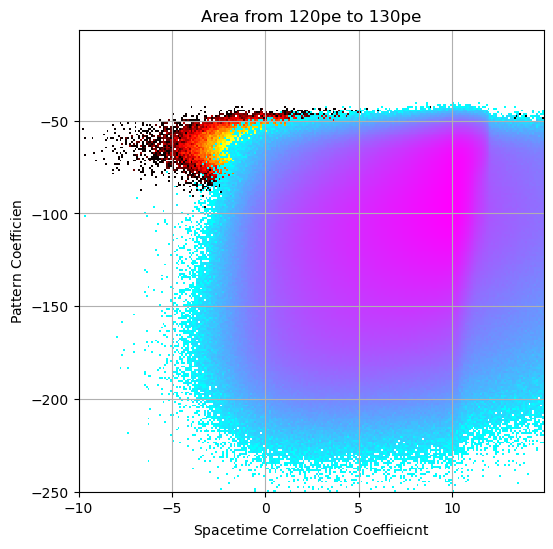

Area range from 120 to 130, DE_num: 56007310



  6%|██████████▌                                                                                                                                                                                   | 1/18 [01:15<21:20, 75.31s/it]

[7.0499999999999945, -65.03476097435558] 0.21565329373579153
126.790405


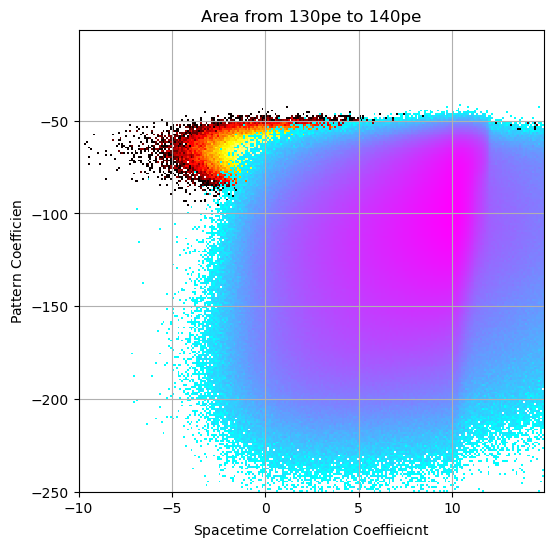

Area range from 130 to 140, DE_num: 25358081



 11%|█████████████████████                                                                                                                                                                         | 2/18 [01:54<14:23, 53.97s/it]

[6.949999999999995, -72.02406843870236] 0.29249725550700006
58.058145


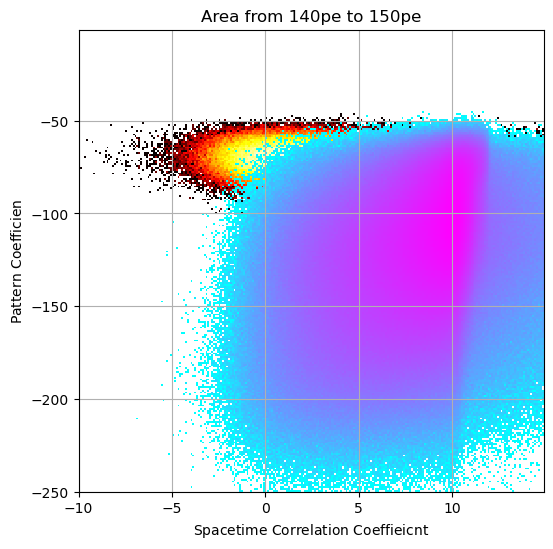

Area range from 140 to 150, DE_num: 11611629



 17%|███████████████████████████████▋                                                                                                                                                              | 3/18 [02:18<10:08, 40.55s/it]

[5.999999999999998, -77.2575589939104] 0.36185718964952507
27.29231


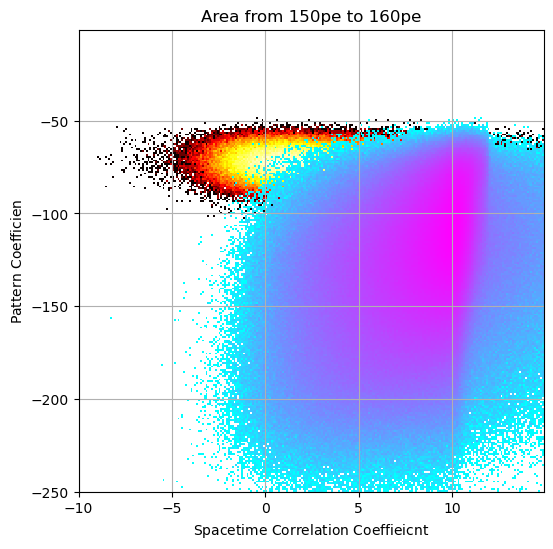

Area range from 150 to 160, DE_num: 5458462



 22%|██████████████████████████████████████████▏                                                                                                                                                   | 4/18 [02:31<06:52, 29.47s/it]

[5.699999999999999, -83.6742645576435] 0.4574609176590101
13.012255000000001


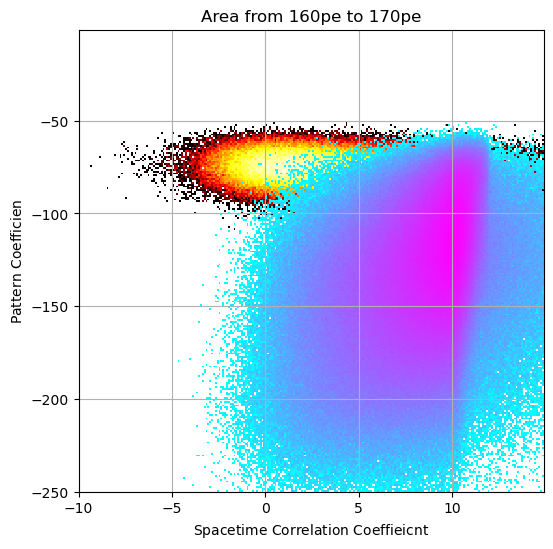

Area range from 160 to 170, DE_num: 2602451



 28%|████████████████████████████████████████████████████▊                                                                                                                                         | 5/18 [02:38<04:40, 21.57s/it]

[6.099999999999998, -90.61149730721095] 0.5329948778387199
6.238020000000001


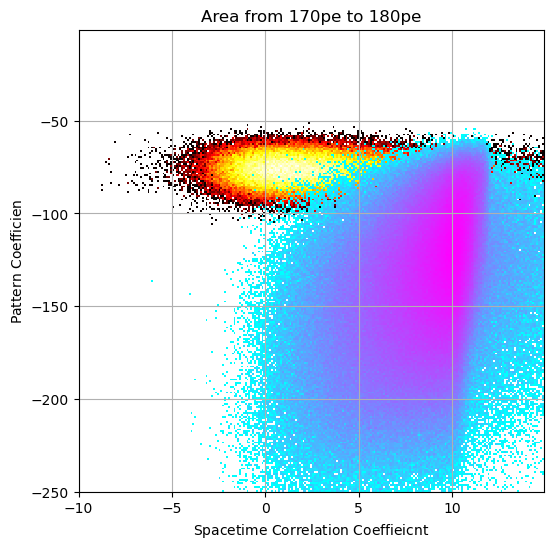

Area range from 170 to 180, DE_num: 1247604



 33%|███████████████████████████████████████████████████████████████▎                                                                                                                              | 6/18 [02:43<03:08, 15.70s/it]

[5.949999999999998, -96.45702925876066] 0.6118825271355788
3.013205


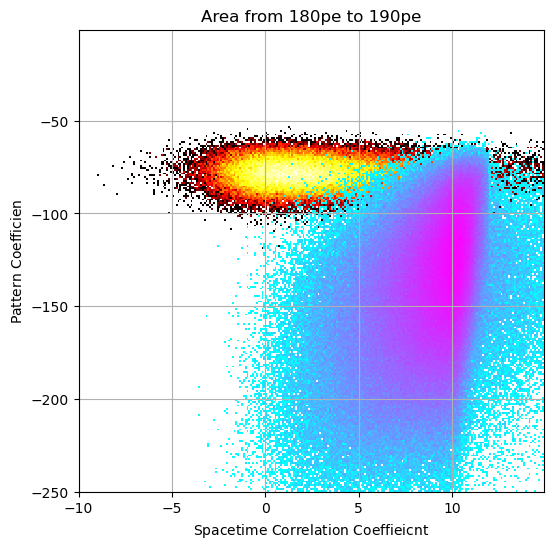

Area range from 180 to 190, DE_num: 602641



 39%|█████████████████████████████████████████████████████████████████████████▉                                                                                                                    | 7/18 [02:47<02:10, 11.91s/it]

[5.699999999999999, -101.07662799810034] 0.666456105521214
1.478865


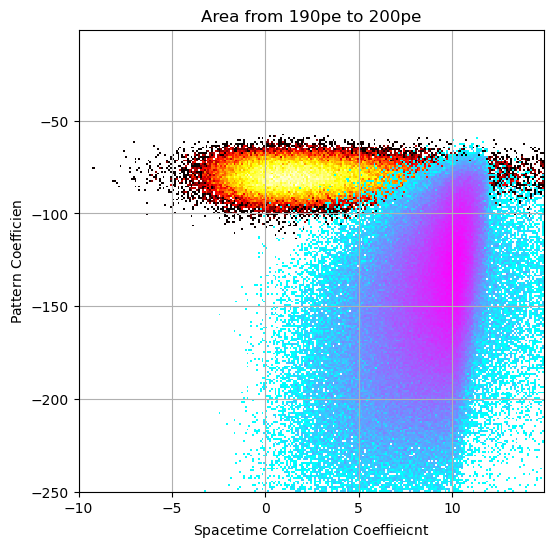

Area range from 190 to 200, DE_num: 295773



 44%|████████████████████████████████████████████████████████████████████████████████████▍                                                                                                         | 8/18 [02:50<01:31,  9.14s/it]

[5.699999999999999, -106.35395226477263] 0.7170960732577991
0.731505


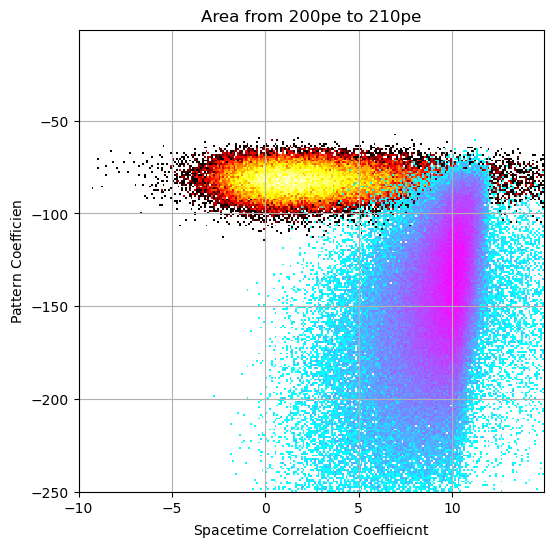

Area range from 200 to 210, DE_num: 146301



 50%|███████████████████████████████████████████████████████████████████████████████████████████████                                                                                               | 9/18 [02:54<01:06,  7.44s/it]

[5.55, -110.7625573135308] 0.7639788548879458
0.3623


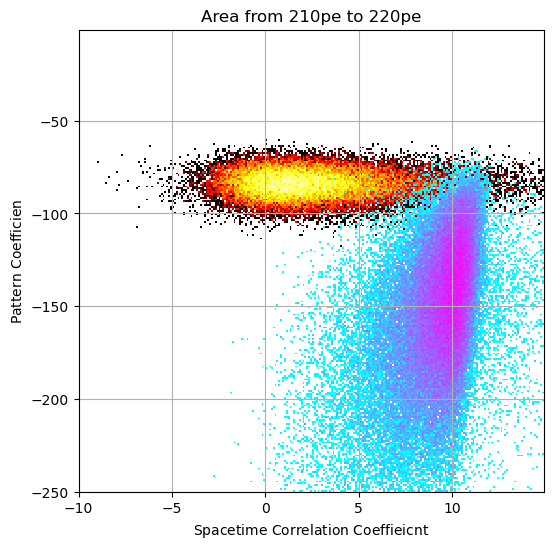

Area range from 210 to 220, DE_num: 72460



 56%|█████████████████████████████████████████████████████████████████████████████████████████████████████████                                                                                    | 10/18 [02:58<00:51,  6.47s/it]

[5.749999999999999, -116.55796676505962] 0.7987526522214364
0.18089000000000002


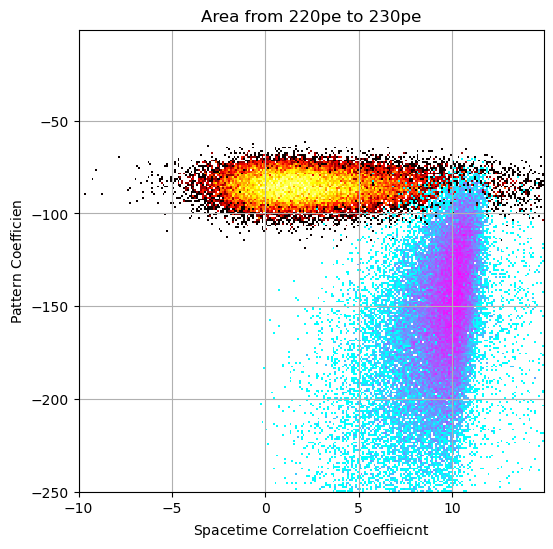

Area range from 220 to 230, DE_num: 36178



 61%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                                                         | 11/18 [03:01<00:37,  5.40s/it]

[7.449999999999993, -124.76092983059094] 0.782972726519108
0.09191500000000001


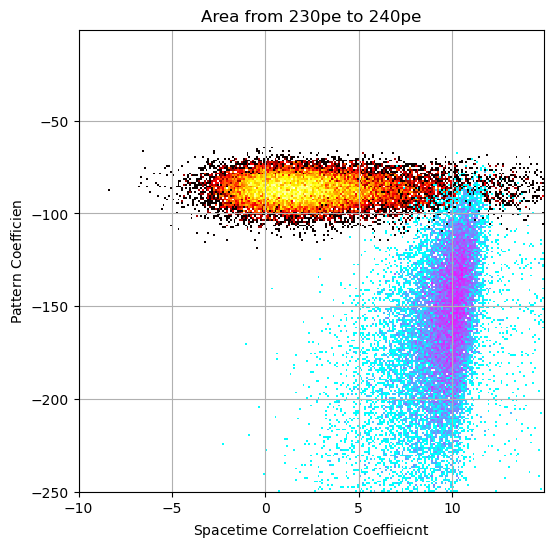

Area range from 230 to 240, DE_num: 18383



 67%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                                               | 12/18 [03:05<00:29,  4.98s/it]

[7.449999999999993, -135.72455524165284] 0.8501355157570282
0.0449


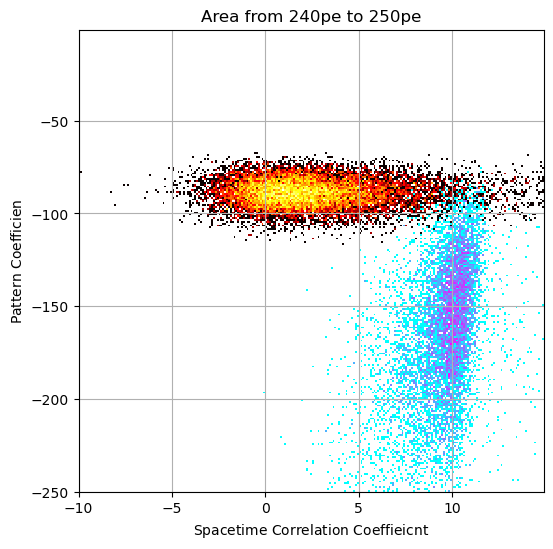

Area range from 240 to 250, DE_num: 8980



 72%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                                    | 13/18 [03:08<00:21,  4.35s/it]

[7.399999999999993, -146.78907553047787] 0.9032504514515906
0.02136


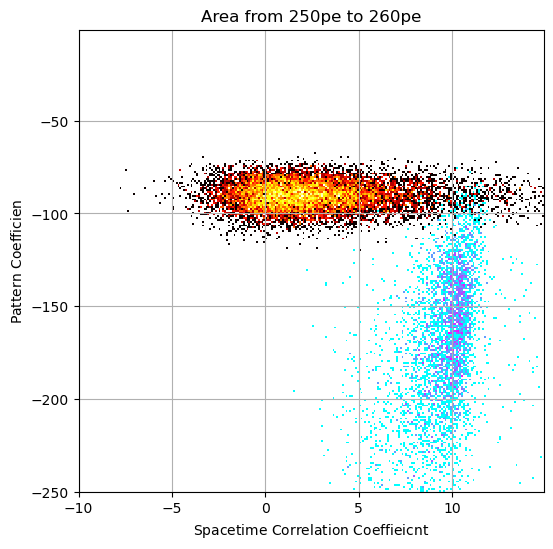

Area range from 250 to 260, DE_num: 4272



 78%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                          | 14/18 [03:12<00:16,  4.11s/it]

[5.799999999999999, -133.4465644653719] 0.8856652205350687
0.009474999999999999


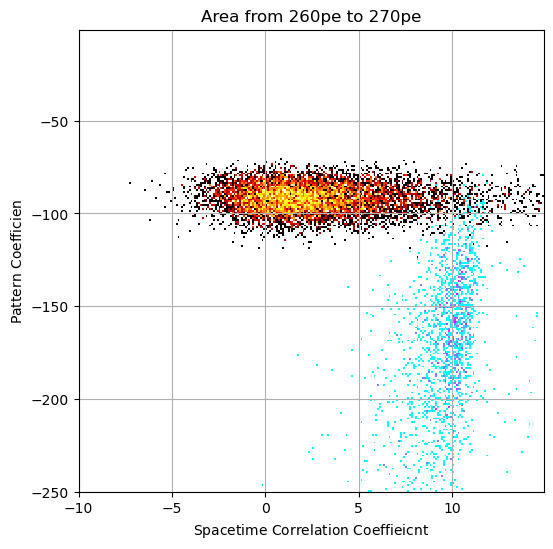

Area range from 260 to 270, DE_num: 1895



 83%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                               | 15/18 [03:14<00:11,  3.75s/it]

[7.449999999999993, -152.91299726782017] 0.9103879259521283
0.004110000000000001


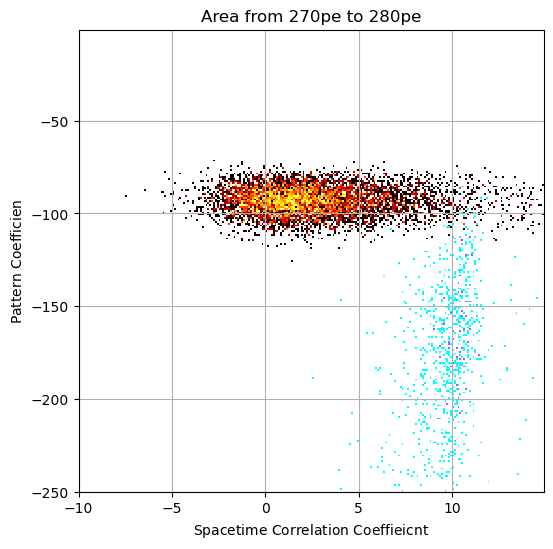

Area range from 270 to 280, DE_num: 822



 89%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                     | 16/18 [03:18<00:07,  3.76s/it]

[6.049999999999998, -149.2866961288189] 0.9372280919825979
0.00176


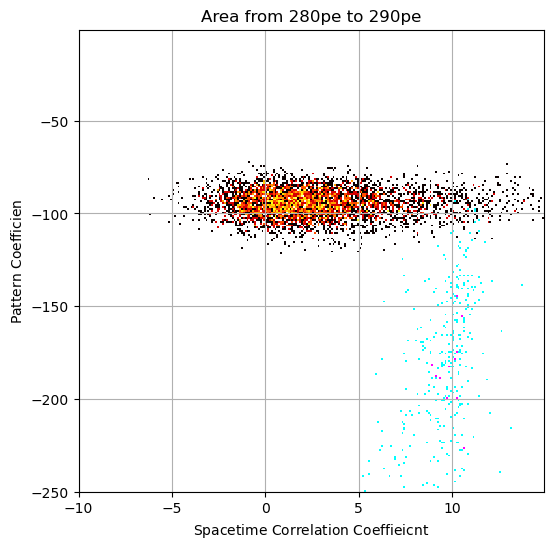

Area range from 280 to 290, DE_num: 352



 94%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌          | 17/18 [03:21<00:03,  3.51s/it]

[6.949999999999995, -164.3775422261414] 0.9502355109563793
0.0006850000000000001


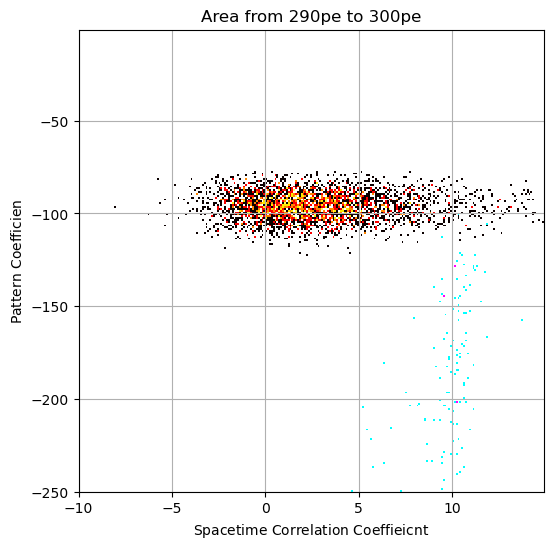

Area range from 290 to 300, DE_num: 137



100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [03:25<00:00, 11.40s/it]

[5.5, -157.6596941145739] 0.9668911335578002


In [72]:
area_range = np.arange(120,300,10)
area_central = []
k_st_max_exposure = []
b_max_exposure = []
exposure_area = []
k_st_list = np.arange(5.5,7.5,0.05)
x_bins = np.arange(-10,15,0.1)
y_bins = np.arange(-250,-0,1)
DE_remain = []

for i in tqdm(range(len(area_range))):
    area_low = area_range[i]
    area_high = area_range[i] + 10
    DE_pe_mask = (pile_up_area > area_low) & (pile_up_area < area_high)
    cevns_pe_mask = (cevns_info['area'] > area_low) & (cevns_info['area'] < area_high)
    print(len(pile_up_area[DE_pe_mask]) * 0.005 * 0.001)
    
    cevns_bins = cevns_info[cevns_pe_mask]
    DE_bins = DE_info[DE_pe_mask]

    plt.figure(figsize=(6,6))  # 调整 figsize 参数以设置合适的宽度和高度
    H = plt.hist2d(cevns_bins['st_cor'], cevns_bins['pattern'], 
                   bins = [x_bins, y_bins], norm=LogNorm(), 
                   alpha = 1,label = 'CEvNS Event', cmap = 'hot')
    H = plt.hist2d(DE_bins['st_cor'], DE_bins['pattern'], 
                   bins = [x_bins, y_bins], norm=LogNorm(), 
                   alpha = 1,label = 'DE Event', cmap = 'cool')
    plt.xlabel(r'$\mathrm{Spacetime\  Correlation\ Coeffieicnt}$')
    plt.ylabel(r'$\mathrm{Pattern\ Coefficien}$')
    plt.title('Area from {}pe to {}pe'.format(area_low, area_high))
    plt.grid()
    plt.show()
    
    print('Area range from {} to {}, DE_num: {}'.format(area_low, area_high, len(pile_up_area[DE_pe_mask])))
    DE_remain.append(len(pile_up_area[DE_pe_mask]) * 0.005 * 0.01)
    exposure = []
    k_list = []
    score_cevns = 0

    for k_st in tqdm(k_st_list):
        score_cevns = cevns_bins['pattern'] - (k_st * cevns_bins['st_cor']) 
        score_DE = DE_bins['pattern'] - (k_st * DE_bins['st_cor'])
        b = np.percentile(score_DE, 100-0.005)
        k_list.append([k_st,b])
        exposure.append(len(score_cevns[score_cevns>b])/len(score_cevns))
    exposure = np.array(exposure)

    # 找到最大值的索引
    index_of_max = np.argmax(exposure)
    print(k_list[index_of_max],np.max(exposure))
    k_st_area, b_area = k_list[index_of_max]
    area_central.append((area_low+area_high)/2)
    k_st_max_exposure.append(k_st_area)
    b_max_exposure.append(b_area)
    exposure_area.append(np.max(exposure))

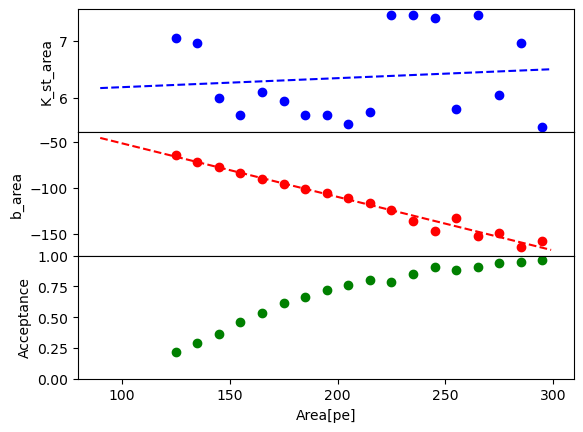

In [76]:
area_range = np.arange(90,300,1)

k_st_coefficients = np.polyfit(area_central, k_st_max_exposure, deg=1)  
k_st_fit = area_range * k_st_coefficients[0] + k_st_coefficients[1] 

b_coefficients = np.polyfit(area_central, b_max_exposure, deg=1)  
b_fit = area_range * b_coefficients[0] + b_coefficients[1] 

# 创建包含三个子图的图形，并设置它们之间的间距为0  
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, gridspec_kw={'hspace': 0})  
  
# 绘制第一个子图  
ax1.scatter(area_central, k_st_max_exposure, color = 'b')  
ax1.plot(area_range, k_st_fit, 'b--')
ax1.set_ylabel('K_st_area')  
  
# 绘制第二个子图，并移除x轴刻度标签以避免重复  
ax2.scatter(area_central, b_max_exposure,  color = 'r')  
ax2.plot(area_range, b_fit,'r--')
ax2.set_ylabel('b_area')  
ax2.tick_params(axis='x', labelbottom=False)  
  
# 绘制第三个子图  
ax3.scatter(area_central, exposure_area,  color = 'g')  
ax3.set_ylabel('Acceptance')  
ax3.set_xlabel('Area[pe]')  # 只在最后一个子图上设置x轴标签  
ax3.set_ylim(0,1)
# 设置标题（可选）  
plt.suptitle('')  
plt.savefig('figure/param_120_300.png')
# 显示图形  
plt.show()

将拟合公式对所有DE以及CEvNS apply
======

In [74]:
score_cevns = cevns_info['pattern'] - ((cevns_info['area'] * k_st_coefficients[0] + k_st_coefficients[1] ) * cevns_info['st_cor']) 
b_cevns = cevns_info['area'] * b_coefficients[0] + b_coefficients[1] 

score_DE = DE_info['pattern'] - ((DE_info['area'] * k_st_coefficients[0] + k_st_coefficients[1] ) * DE_info['st_cor']) 
b_DE = DE_info['area'] * b_coefficients[0] + b_coefficients[1] 

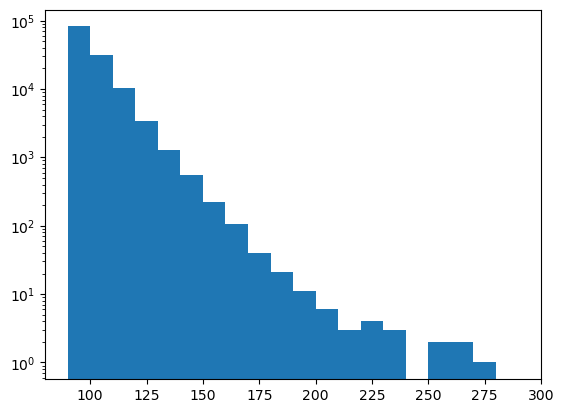

In [77]:
DE_pattern_cut_mask = score_DE > b_DE
DE_strange_mask = (DE_info['area'] > 225) & (DE_info['area'] < 275)
plt.hist(DE_info[DE_pattern_cut_mask]['area'],bins = np.arange(90,300,10))
plt.yscale('log')
plt.savefig('figure/DE_spectrum_120_300.png')
plt.show()

In [86]:
time_length = 4.261571815718157 / 50 * 18459 * 5  # hour
DE_spectrum_original,bins_edge = np.histogram(DE_info[DE_pattern_cut_mask]['area'], bins=np.arange(90,301,10))
DE_rate = DE_spectrum_original / time_length * 24 / 32 / 10
DE_rate_error =  DE_spectrum_original**0.5 / time_length * 24 / 32 / 10

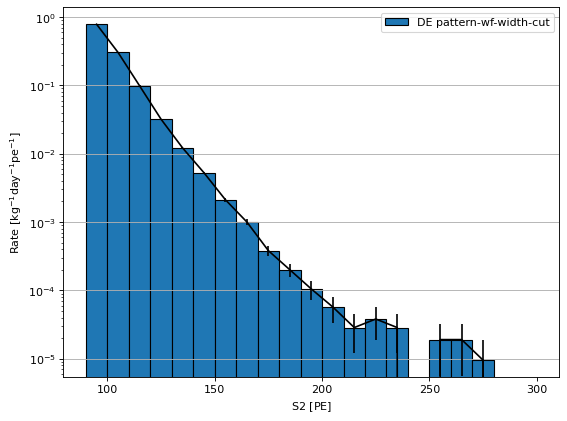

In [88]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6), dpi=80)

# 创建一个柱状图并添加误差条
ax.bar((bins_edge[1:] + bins_edge[:-1])/2, DE_rate, edgecolor = "black", label = "DE pattern-wf-width-cut",width=10,)
ax.errorbar((bins_edge[1:] + bins_edge[:-1])/2, DE_rate, yerr=DE_rate_error, color = "black")

ax.set_xlabel(r"$\mathrm{S2\ [PE]}$")
ax.set_ylabel(r"$\mathrm{Rate\ [kg^{-1} day^{-1} pe^{-1}]}$")
ax.set_yscale("log")

# 设置y轴的刻度为每个10的n次方
# ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0))
# ax.tick_params(direction='in')
# 增加背景刻度线
ax.grid(which='major', axis='y')

plt.legend()
plt.savefig("figure/DE_rate_after_avg_cut.pdf")

plt.show()

In [67]:
DE_strange = DE_info[DE_strange_mask * DE_pattern_cut_mask]

In [68]:
DE_strange['e_num']

array([5, 7, 7, 6, 5, 7, 6, 7, 6, 5, 5, 6, 6, 6, 6, 7, 6, 7, 7, 7, 7, 6,
       7, 5, 7, 7, 7, 6, 7, 5, 7, 5, 6, 5, 7, 5, 6, 7, 7, 5, 5, 6, 6, 7,
       6, 7, 7, 6, 6, 7, 6, 6, 6, 6, 5, 7, 7, 6, 7, 6, 7, 7, 6, 5, 7, 7,
       7, 4, 7, 5, 7, 6, 6, 5, 7, 7, 6, 5, 6, 5, 6, 6, 6, 6, 6, 5, 5, 5,
       6, 7, 7, 7, 6, 7, 6, 6, 7, 6, 7, 5, 6, 6, 7, 7, 6, 6, 7, 6, 6, 6,
       5, 6, 6, 7, 6, 6, 6, 5, 7, 5, 7, 7, 7, 6, 7, 7, 6, 6, 6, 5, 4, 5,
       5, 7, 6, 5, 7, 6, 6, 7, 7, 6, 5, 7, 6, 5, 5, 7, 6, 7, 6, 7, 6, 6,
       7, 5, 6, 5, 7, 7, 6, 6, 6, 7, 7, 5, 6, 6, 7, 7, 6, 6, 7, 7, 7, 7,
       6, 6, 7, 7, 7, 4, 6, 6, 7, 7, 6, 6, 5, 7, 6, 6, 7, 6, 7, 6, 6, 7,
       7, 6, 7, 6, 6, 6, 7, 5, 7, 7, 7, 7, 7, 7, 6, 7, 6, 7, 6, 5, 7, 5,
       5, 6, 5, 7, 7, 5, 5, 7, 7, 6, 7, 6, 7, 5, 5, 5, 6, 6, 6, 7, 7, 6,
       5, 6, 7, 5, 6, 6, 7, 7, 7, 7, 5, 6, 7, 6, 7, 7, 5, 7, 5, 7, 6, 7,
       6, 6, 5, 6, 5, 7, 7, 7, 6, 6, 6, 6, 6, 6, 7, 7, 4, 6, 7, 7, 5, 6,
       7, 6, 7, 7, 7, 6, 5, 7, 6, 5, 7, 5, 6, 5, 6,